In [2]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import boxcox
from statsmodels.stats.anova import anova_lm

#### Full model summary

In [3]:
#Load model-ready data
df = pd.read_csv("kidney_disease_model_ready.csv")

# Define response variable
y = df["sc"]  # serum creatinine

#Build full predictor matrix drop response
X_full = df.drop(columns=["sc"])

#Add intercept and fit FULL model
X_full_const = sm.add_constant(X_full)
full_model = sm.OLS(y, X_full_const).fit()

print(full_model.summary())
params = full_model.params  
equation = "sc_hat = "




                            OLS Regression Results                            
Dep. Variable:                     sc   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     41.11
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           1.46e-49
Time:                        18:46:48   Log-Likelihood:                -236.48
No. Observations:                 158   AIC:                             521.0
Df Residuals:                     134   BIC:                             594.5
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -10.8754     30.675     -0.355      

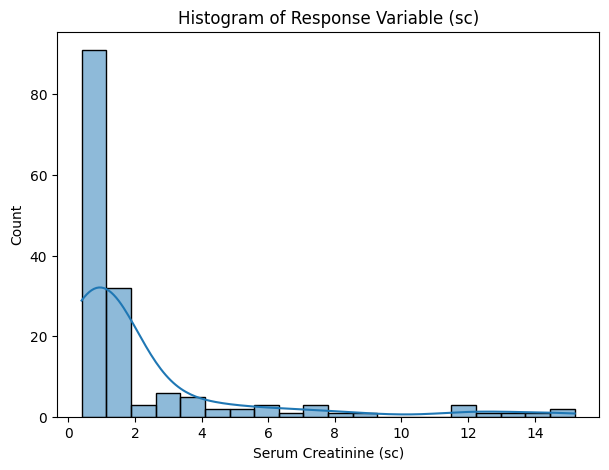

In [4]:
# Histogram of serum creatinine (sc)
plt.figure(figsize=(7,5))
sns.histplot(df["sc"], kde=True, bins=20)
plt.xlabel("Serum Creatinine (sc)")
plt.title("Histogram of Response Variable (sc)")
plt.show()

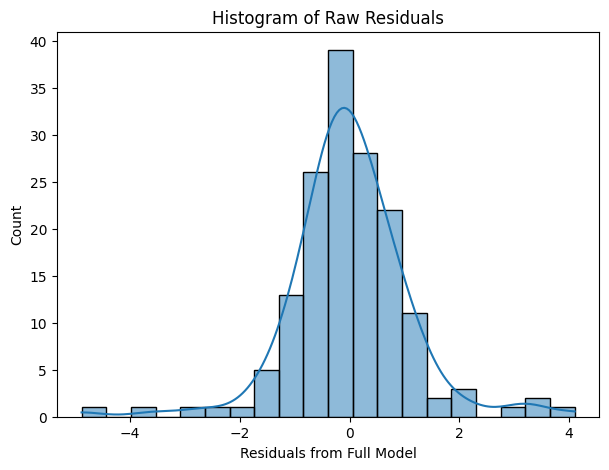

In [5]:
# Raw residuals of full model
resid_full = full_model.resid

plt.figure(figsize=(7,5))
sns.histplot(resid_full, kde=True, bins=20)
plt.xlabel("Residuals from Full Model")
plt.title("Histogram of Raw Residuals")
plt.show()

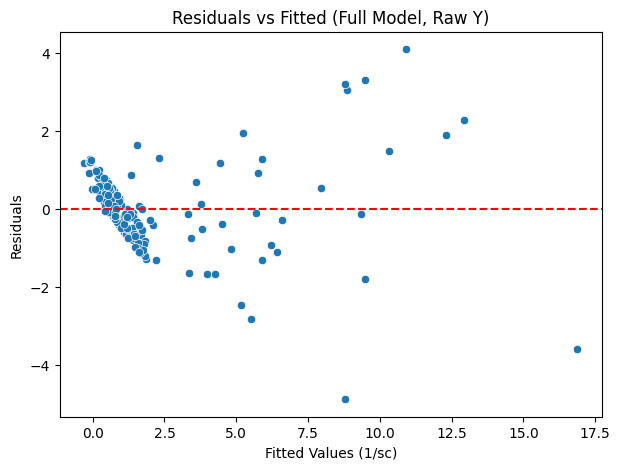

In [6]:
fitted_vals = full_model.fittedvalues
residuals = full_model.resid

plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values (1/sc)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Full Model, Raw Y)")
plt.show()

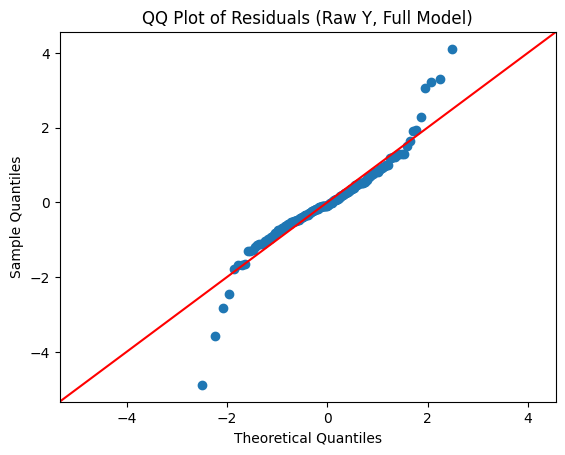

In [7]:
sm.qqplot(residuals, line='45')
plt.title("QQ Plot of Residuals (Raw Y, Full Model)")
plt.show()


#### Full model summary

In [8]:

y_bc, lambda_opt = boxcox(df["sc"])
print("Optimal Box-Cox lambda:", lambda_opt)

Optimal Box-Cox lambda: -0.7108624125483377


#### Full Model Summary with Original Y

In [9]:
y_raw = df["sc"]
y_trans = y


#build predictor matrix
X_full = df.drop(columns=["sc"]) 
X_full_const = sm.add_constant(X_full)

#fit transformed model
full_model_trans = sm.OLS(y_trans, X_full_const).fit()

print(full_model_trans.summary())


                            OLS Regression Results                            
Dep. Variable:                     sc   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     41.11
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           1.46e-49
Time:                        18:46:49   Log-Likelihood:                -236.48
No. Observations:                 158   AIC:                             521.0
Df Residuals:                     134   BIC:                             594.5
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -10.8754     30.675     -0.355      

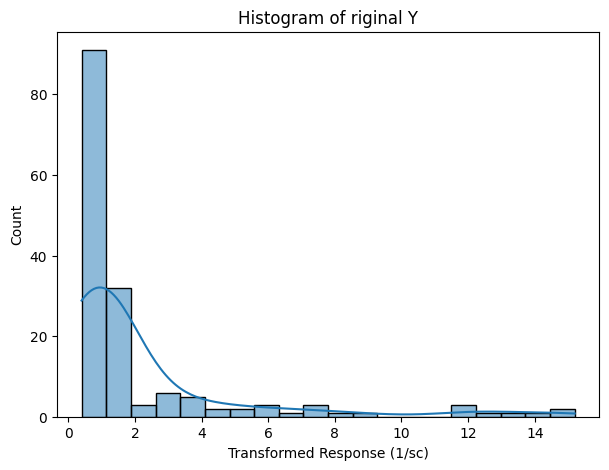

In [10]:
# Histogram of transformed response y_trans = 1/sc
plt.figure(figsize=(7,5))
sns.histplot(y_trans, kde=True, bins=20)
plt.xlabel("Transformed Response (1/sc)")
plt.title("Histogram of riginal Y")
plt.show()


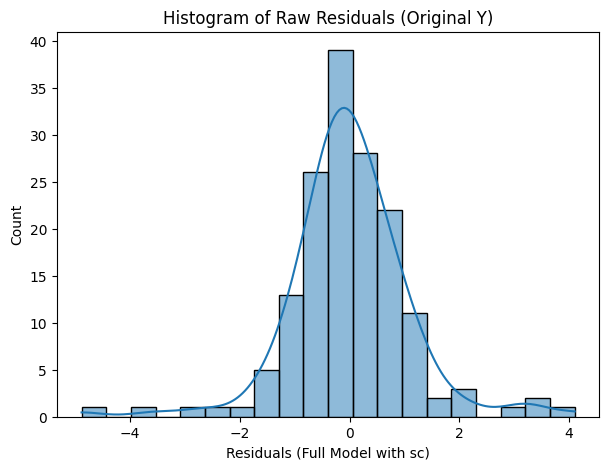

In [11]:
# Histogram of residuals from the full model with transformed Y
residuals_trans = full_model_trans.resid

plt.figure(figsize=(7,5))
sns.histplot(residuals_trans, kde=True, bins=20)
plt.xlabel("Residuals (Full Model with sc)")
plt.title("Histogram of Raw Residuals (Original Y)")
plt.show()


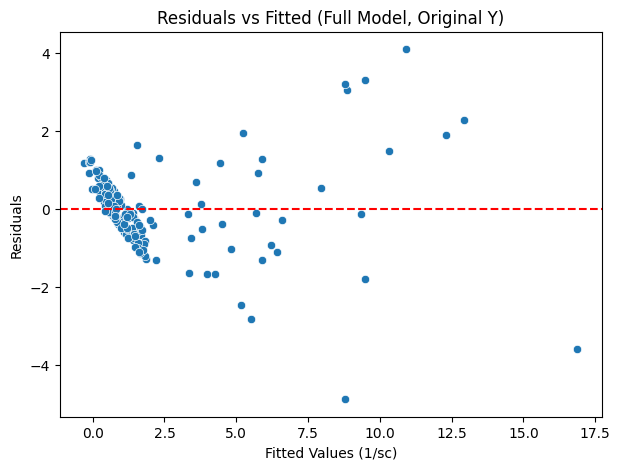

In [12]:
fitted_vals = full_model_trans.fittedvalues
residuals = full_model_trans.resid

plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values (1/sc)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Full Model, Original Y)")
plt.show()

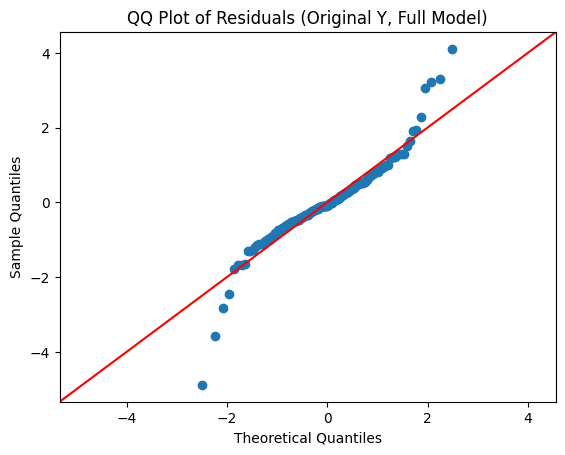

In [13]:
sm.qqplot(residuals, line='45')
plt.title("QQ Plot of Residuals (Original Y, Full Model)")
plt.show()


#### Running VIF with Original Y

In [14]:
#VIF on reduced
X_full_const = sm.add_constant(X_full)
vif_data = pd.DataFrame()
vif_data["feature"] = X_full_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_full_const.values, i)
                   for i in range(X_full_const.shape[1])]

print(vif_data)

        feature            VIF
0         const  107932.677571
1           age       1.270614
2            bp       1.473606
3            sg       3.220942
4            al       5.747374
5            su       3.464760
6           bgr       3.590615
7            bu       3.178348
8           sod       2.139629
9           pot       1.626929
10         hemo       5.394035
11          pcv       5.495848
12           wc       1.489172
13           rc       2.895132
14   rbc_normal       2.430211
15    pc_normal       4.239018
16  pcc_present       2.365934
17   ba_present       2.182825
18      htn_yes       5.715146
19       dm_yes       5.142223
20      cad_yes       1.933202
21   appet_poor       2.752290
22       pe_yes       3.800977
23      ane_yes       3.350359


#### Backward Elimination for variable selection

In [15]:
alpha = 0.10 

X_current = X_full.copy()
removed_vars = []
step = 0

while True:
    X_const = sm.add_constant(X_current)
    model = sm.OLS(y_trans, X_const).fit()

    # p-values for all predictors except the intercept
    pvals = model.pvalues.drop("const")
    worst_p = pvals.max()
    worst_var = pvals.idxmax()

    print(f"Step {step}: max p-value = {worst_p:.4f} for variable '{worst_var}'")

    # stop if all remaining variables are significant at alpha
    if worst_p < alpha:
        print("\nAll remaining variables have p-values < alpha.")
        break
    # otherwise drop the worst variable and continue
    removed_vars.append((worst_var, worst_p))
    X_current = X_current.drop(columns=[worst_var])
    step += 1

print("\nVariables removed (in order):")
for var, p in removed_vars:
    print(f"  {var}: p = {p:.4f}")

print("\nFinal predictor set:")
print(list(X_current.columns))



Step 0: max p-value = 0.9924 for variable 'dm_yes'
Step 1: max p-value = 0.9787 for variable 'sod'
Step 2: max p-value = 0.7767 for variable 'cad_yes'
Step 3: max p-value = 0.6349 for variable 'age'
Step 4: max p-value = 0.6040 for variable 'sg'
Step 5: max p-value = 0.4424 for variable 'htn_yes'
Step 6: max p-value = 0.3161 for variable 'hemo'
Step 7: max p-value = 0.2977 for variable 'pcc_present'
Step 8: max p-value = 0.2454 for variable 'su'
Step 9: max p-value = 0.5402 for variable 'bgr'
Step 10: max p-value = 0.1432 for variable 'rbc_normal'
Step 11: max p-value = 0.1175 for variable 'rc'
Step 12: max p-value = 0.0763 for variable 'appet_poor'

All remaining variables have p-values < alpha.

Variables removed (in order):
  dm_yes: p = 0.9924
  sod: p = 0.9787
  cad_yes: p = 0.7767
  age: p = 0.6349
  sg: p = 0.6040
  htn_yes: p = 0.4424
  hemo: p = 0.3161
  pcc_present: p = 0.2977
  su: p = 0.2454
  bgr: p = 0.5402
  rbc_normal: p = 0.1432
  rc: p = 0.1175

Final predictor set:
[

In [16]:
X_reduced_const = sm.add_constant(X_current)
reduced_model = sm.OLS(y_trans, X_reduced_const).fit()
print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     sc   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     86.68
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           2.84e-58
Time:                        18:46:49   Log-Likelihood:                -241.80
No. Observations:                 158   AIC:                             507.6
Df Residuals:                     146   BIC:                             544.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1387      1.355      0.102      0.9

#### Anova Tests with Full model Original Y and Reduced Model Originla Y

In [17]:
X_full_const = sm.add_constant(X_full)
full_model_trans = sm.OLS(y_trans, X_full_const).fit()

reduced_predictors = ['bp', 'al', 'bu', 'pot', 'pcv', 'wc', 'pc_normal', 'ba_present', 'appet_poor', 'pe_yes', 'ane_yes']
X_reduced = X_full[reduced_predictors]
X_reduced_const = sm.add_constant(X_reduced)
reduced_model_trans = sm.OLS(y_trans, X_reduced_const).fit()

resid = reduced_model_trans.resid
fitted = reduced_model_trans.fittedvalues

anova_results = anova_lm(reduced_model_trans, full_model_trans)

print(anova_results)

   df_resid         ssr  df_diff    ss_diff         F    Pr(>F)
0     146.0  197.459493      0.0        NaN       NaN       NaN
1     134.0  184.579206     12.0  12.880287  0.779231  0.670915


#### Diagnostics for Reduced Model

In [18]:
#Influencial Analysis values 
influence = reduced_model_trans.get_influence()
studentized_resid = influence.resid_studentized_external
hat_values = influence.hat_matrix_diag
cooks_d, _ = influence.cooks_distance

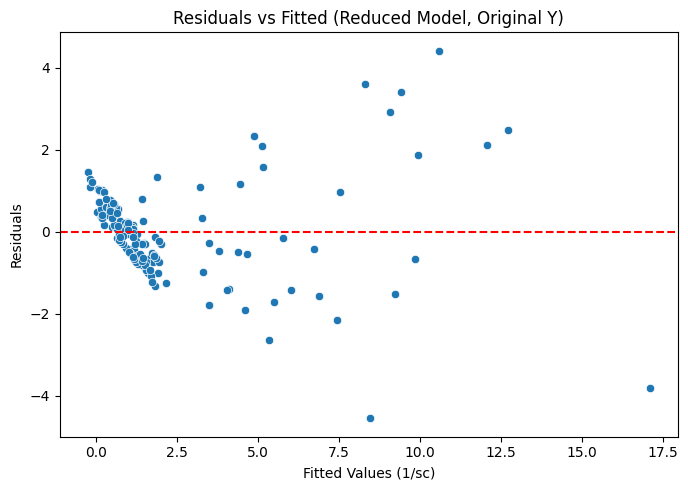

In [19]:
#Residuals vs Fitted Values Plots
plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted, y=resid)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values (1/sc)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Reduced Model, Original Y)")
plt.tight_layout()
plt.show()

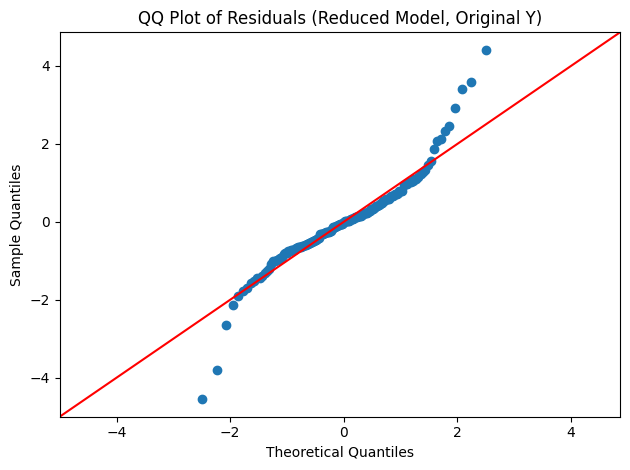

In [20]:
# QQ Plot
sm.qqplot(resid, line="45")
plt.title("QQ Plot of Residuals (Reduced Model, Original Y)")
plt.tight_layout()
plt.show()

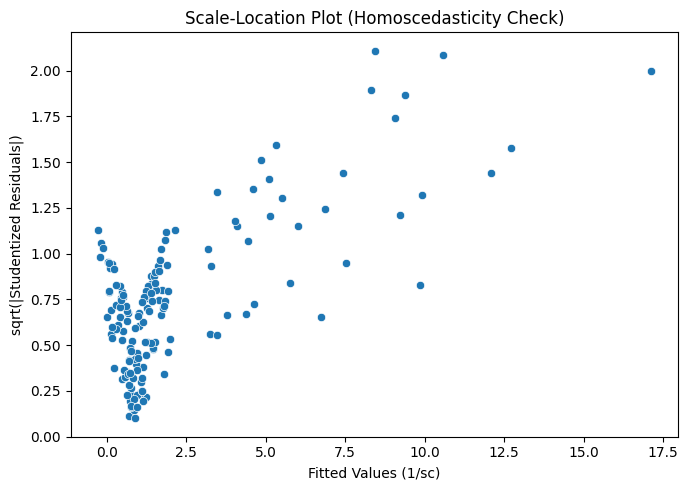

In [21]:
# Scale location plot
plt.figure(figsize=(7,5))
sqrt_abs_sr = np.sqrt(np.abs(studentized_resid))
sns.scatterplot(x=fitted, y=sqrt_abs_sr)
plt.xlabel("Fitted Values (1/sc)")
plt.ylabel("sqrt(|Studentized Residuals|)")
plt.title("Scale-Location Plot (Homoscedasticity Check)")
plt.tight_layout()
plt.show()

In [22]:
#cooks distance
plt.figure(figsize=(7,5))
plt.stem(np.arange(n), cooks_d)
plt.axhline(4/n, color="red", linestyle="--", label="4/n threshold")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for Each Observation")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'n' is not defined

<Figure size 700x500 with 0 Axes>

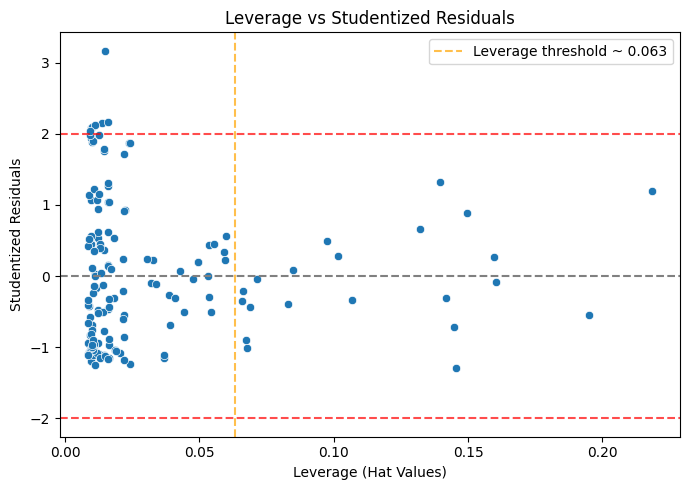

In [ ]:
#leverage vs studentized residuals
plt.figure(figsize=(7,5))
sns.scatterplot(x=hat_values, y=studentized_resid)
plt.axhline(0, color="grey", linestyle="--")
plt.xlabel("Leverage (Hat Values)")
plt.ylabel("Studentized Residuals")
plt.title("Leverage vs Studentized Residuals")
# Optional reference lines:
# 2 and -2 for residuals, and 2*(p+1)/n for leverage
p = X_reduced_const.shape[1] - 1  # number of predictors (4)
lev_threshold = 2 * (p + 1) / n
plt.axhline(2, color="red", linestyle="--", alpha=0.7)
plt.axhline(-2, color="red", linestyle="--", alpha=0.7)
plt.axvline(lev_threshold, color="orange", linestyle="--", alpha=0.7,
            label=f"Leverage threshold ~ {lev_threshold:.3f}")
plt.legend()
plt.tight_layout()
plt.show()